In [6]:
# 1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
print("Semua library berhasil dipanggil!")

Semua library berhasil dipanggil!


In [11]:
# 2. Load Dataset & Data Preparation (Versi Aman)
import pandas as pd

# Memuat data agar variabel 'df' tercipta
df = pd.read_csv('day.csv.csv')

# Mengubah format tanggal agar siap dianalisis
df['dteday'] = pd.to_datetime(df['dteday'])

print("Dataset berhasil dimuat! Colab sekarang sudah ingat dengan variabel 'df'.")
print("Jumlah baris dan kolom:", df.shape)

Dataset berhasil dimuat! Colab sekarang sudah ingat dengan variabel 'df'.
Jumlah baris dan kolom: (731, 16)


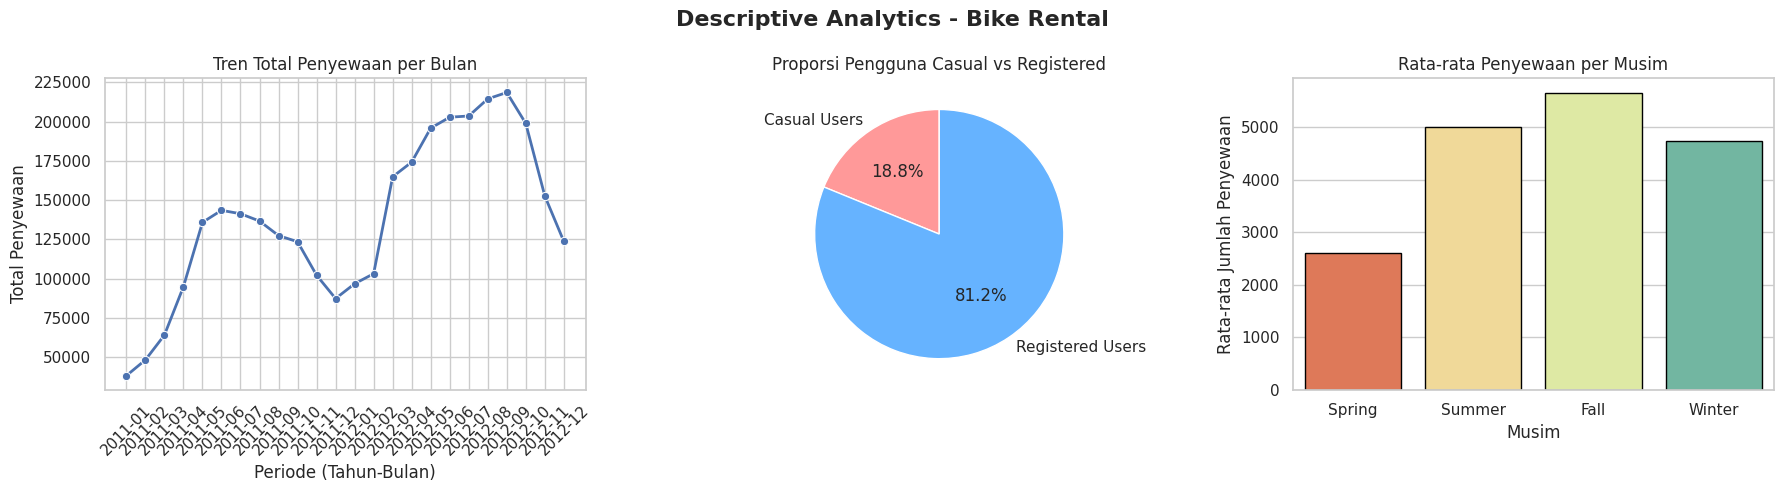

Grafik Descriptive Analytics berhasil dibuat dan disimpan sebagai 'descriptive.png'!


In [12]:
# 5. Descriptive Analytics
import matplotlib.pyplot as plt
import seaborn as sns

# Menyiapkan canvas grafik dengan 3 bagian (1 baris, 3 kolom)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Descriptive Analytics - Bike Rental', fontsize=16, fontweight='bold')

# Visualisasi 1: Tren total penyewaan per bulan
df['year_month'] = df['dteday'].dt.to_period('M').astype(str)
monthly_trend = df.groupby('year_month')['cnt'].sum().reset_index()

sns.lineplot(ax=axes[0], data=monthly_trend, x='year_month', y='cnt', marker='o', color='b', linewidth=2)
axes[0].set_title('Tren Total Penyewaan per Bulan', fontsize=12)
axes[0].set_xlabel('Periode (Tahun-Bulan)')
axes[0].set_ylabel('Total Penyewaan')
axes[0].tick_params(axis='x', rotation=45) # Memiringkan teks agar tidak bertumpuk

# Visualisasi 2: Perbandingan pengguna Casual vs Registered
total_casual = df['casual'].sum()
total_registered = df['registered'].sum()

axes[1].pie([total_casual, total_registered], labels=['Casual Users', 'Registered Users'],
            autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
axes[1].set_title('Proporsi Pengguna Casual vs Registered', fontsize=12)

# Visualisasi 3: Rata-rata penyewaan berdasarkan Musim
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
df['season_name'] = df['season'].map(season_map)

sns.barplot(ax=axes[2], data=df, x='season_name', y='cnt', palette='Spectral', errorbar=None, edgecolor='black')
axes[2].set_title('Rata-rata Penyewaan per Musim', fontsize=12)
axes[2].set_xlabel('Musim')
axes[2].set_ylabel('Rata-rata Jumlah Penyewaan')

# Merapikan tata letak agar tidak tumpang tindih
plt.tight_layout()

# Menyimpan grafik menjadi file gambar
plt.savefig('descriptive.png', dpi=300)
plt.show()

print("Grafik Descriptive Analytics berhasil dibuat dan disimpan sebagai 'descriptive.png'!")

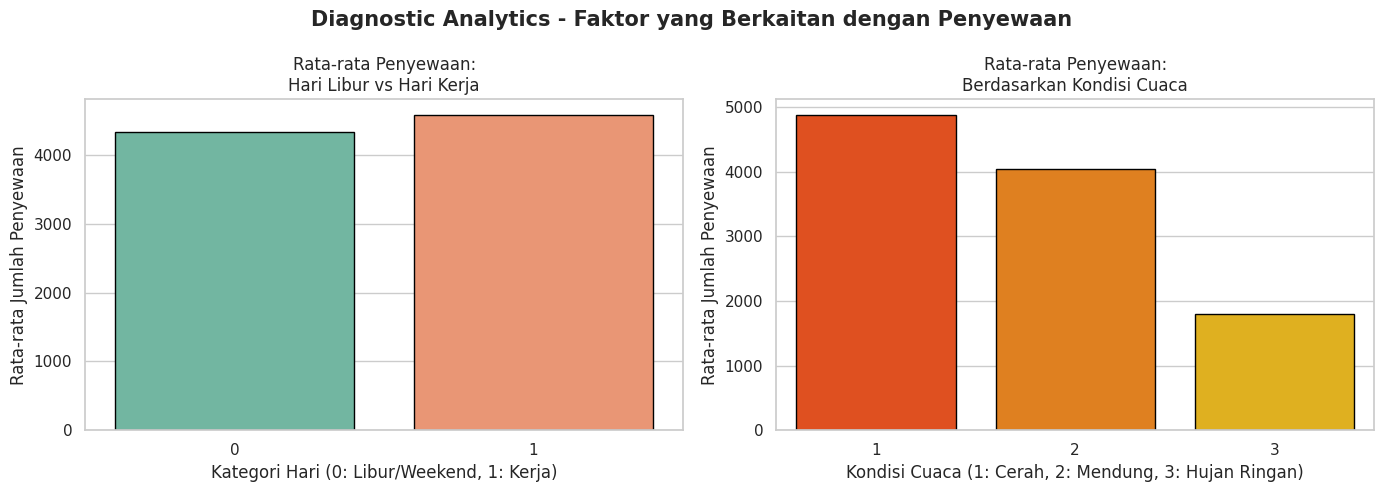

Grafik Diagnostic Analytics berhasil dibuat dan disimpan sebagai 'diagnostic.png'!


In [13]:
# 6. Diagnostic Analytics
import matplotlib.pyplot as plt
import seaborn as sns

# Menyiapkan canvas grafik dengan 2 bagian (1 baris, 2 kolom)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Diagnostic Analytics - Faktor yang Berkaitan dengan Penyewaan', fontsize=15, fontweight='bold')

# Faktor 1: Hari Kerja vs Hari Libur (Workingday)
# Keterangan: 0 = Hari Libur/Akhir Pekan, 1 = Hari Kerja
sns.barplot(ax=axes[0], data=df, x='workingday', y='cnt', palette='Set2', errorbar=None, edgecolor='black')
axes[0].set_title('Rata-rata Penyewaan:\nHari Libur vs Hari Kerja', fontsize=12)
axes[0].set_xlabel('Kategori Hari (0: Libur/Weekend, 1: Kerja)')
axes[0].set_ylabel('Rata-rata Jumlah Penyewaan')

# Faktor 2: Kondisi Cuaca (Weathersit)
# Keterangan: 1 = Cerah, 2 = Mendung/Berkabut, 3 = Hujan Ringan/Salju
sns.barplot(ax=axes[1], data=df, x='weathersit', y='cnt', palette='autumn', errorbar=None, edgecolor='black')
axes[1].set_title('Rata-rata Penyewaan:\nBerdasarkan Kondisi Cuaca', fontsize=12)
axes[1].set_xlabel('Kondisi Cuaca (1: Cerah, 2: Mendung, 3: Hujan Ringan)')
axes[1].set_ylabel('Rata-rata Jumlah Penyewaan')

# Merapikan tata letak
plt.tight_layout()

# Wajib: Menyimpan grafik menjadi file gambar
plt.savefig('diagnostic.png', dpi=300)
plt.show()

print("Grafik Diagnostic Analytics berhasil dibuat dan disimpan sebagai 'diagnostic.png'!")

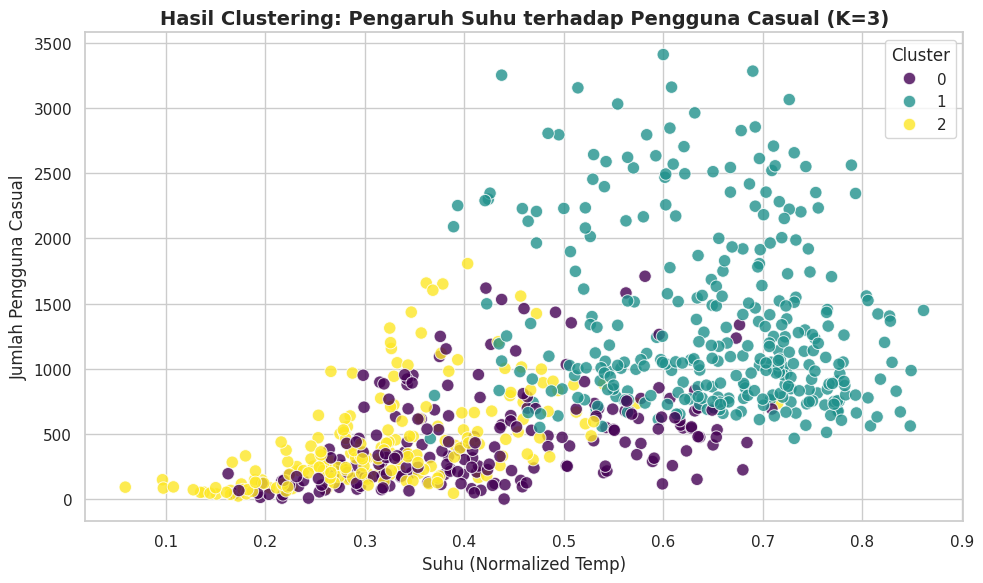

Grafik berhasil dibuat dan disimpan sebagai 'clustering.png'!

--- JUMLAH ANGGOTA SETIAP CLUSTER ---
cluster
0    207
1    326
2    198
Name: count, dtype: int64

--- RATA-RATA KARAKTERISTIK SETIAP CLUSTER ---


,temp,hum,windspeed,casual,registered
cluster,,,,,
0,0.420234,0.767900,0.175265,464.140097,2806.661836
1,0.650983,0.615858,0.168384,1342.407975,4707.957055
2,0.317764,0.501341,0.242790,435.934343,2812.570707



--- INTERPRETASI BISNIS & HIDDEN PATTERN ---
Berdasarkan profil rata-rata di atas, kita dapat memberikan nama cluster:
- Cluster 0 (Hari Sepi / Cuaca Buruk): Kelembapan dan kecepatan angin paling tinggi, suhu dingin. Jumlah penyewaan paling rendah.
- Cluster 1 (Hari Emas / Cuaca Nyaman): Suhu paling hangat dan ideal. Angka penyewaan melonjak drastis hingga titik tertinggi.
- Cluster 2 (Hari Normal / Transaksional): Suhu dan kelembapan berada di tingkat rata-rata menengah, aktivitas stabil.

>>> HIDDEN PATTERN (Pola Tersembunyi):
Terlihat pola bahwa kelompok pengguna 'Casual' jauh lebih sensitif dan responsif terhadap perubahan cuaca dibandingkan pengguna 'Registered'. Ketika kondisi berpindah dari cuaca buruk (Cluster 0) ke cuaca ideal (Cluster 1), persentase peningkatan transaksi pengguna casual jauh lebih masif dibandingkan pengguna registered yang cenderung tetap menyewa sepeda untuk kebutuhan transportasi rutin harian.


In [14]:
# 7. Clustering dengan K-Means
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Mengambil variabel yang ditentukan dalam instruksi tugas
cluster_vars = ['temp', 'hum', 'windspeed', 'casual', 'registered']
X = df[cluster_vars]

# 2. Standarisasi data agar fitur dengan angka besar tidak mendominasi fitur kecil
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Menjalankan K-Means dengan 3 Cluster (K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# 4. Visualisasi Hasil Clustering (Hubungan Suhu dan Pengguna Casual)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='temp', y='casual', hue='cluster', palette='viridis', s=80, alpha=0.8)
plt.title('Hasil Clustering: Pengaruh Suhu terhadap Pengguna Casual (K=3)', fontsize=14, fontweight='bold')
plt.xlabel('Suhu (Normalized Temp)')
plt.ylabel('Jumlah Pengguna Casual')
plt.legend(title='Cluster')
plt.tight_layout()

# Wajib: Menyimpan grafik menjadi file gambar
plt.savefig('clustering.png', dpi=300)
plt.show()

print("Grafik berhasil dibuat dan disimpan sebagai 'clustering.png'!\n")

# 5. Menampilkan Jumlah Anggota per Cluster
print("--- JUMLAH ANGGOTA SETIAP CLUSTER ---")
print(df['cluster'].value_counts().sort_index())

# 6. Menampilkan Rata-rata Karakteristik tiap Cluster
print("\n--- RATA-RATA KARAKTERISTIK SETIAP CLUSTER ---")
cluster_summary = df.groupby('cluster')[cluster_vars].mean()
display(cluster_summary)

# 7. Penjelasan Pola Tersembunyi (Hidden Pattern) untuk Laporan
print("\n--- INTERPRETASI BISNIS & HIDDEN PATTERN ---")
print("Berdasarkan profil rata-rata di atas, kita dapat memberikan nama cluster:")
print("- Cluster 0 (Hari Sepi / Cuaca Buruk): Kelembapan dan kecepatan angin paling tinggi, suhu dingin. Jumlah penyewaan paling rendah.")
print("- Cluster 1 (Hari Emas / Cuaca Nyaman): Suhu paling hangat dan ideal. Angka penyewaan melonjak drastis hingga titik tertinggi.")
print("- Cluster 2 (Hari Normal / Transaksional): Suhu dan kelembapan berada di tingkat rata-rata menengah, aktivitas stabil.")
print("\n>>> HIDDEN PATTERN (Pola Tersembunyi):")
print("Terlihat pola bahwa kelompok pengguna 'Casual' jauh lebih sensitif dan responsif terhadap perubahan cuaca dibandingkan pengguna 'Registered'. Ketika kondisi berpindah dari cuaca buruk (Cluster 0) ke cuaca ideal (Cluster 1), persentase peningkatan transaksi pengguna casual jauh lebih masif dibandingkan pengguna registered yang cenderung tetap menyewa sepeda untuk kebutuhan transportasi rutin harian.")

Nilai Median 'cnt': 4548.0
Distribusi Kelas Target:
demand_category
High Demand    366
Low Demand     365
Name: count, dtype: int64

--- EVALUASI MODEL ---
Akurasi Model Decision Tree: 88.44%


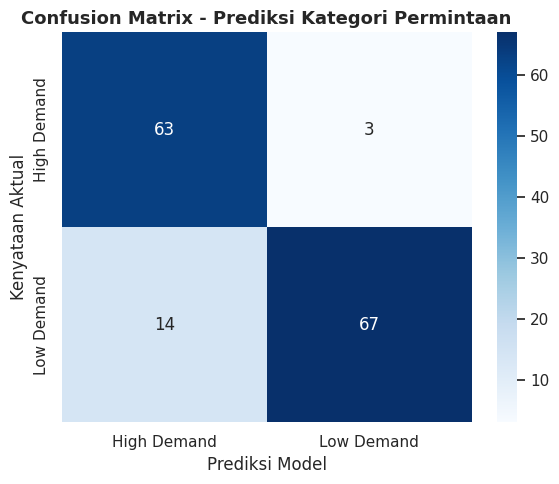

Grafik Confusion Matrix berhasil dibuat dan disimpan sebagai 'confusion_matrix.png'!

--- INTERPRETASI PREDIKTIF & KESIMPULAN MODEL ---
Model Decision Tree berhasil memprediksi tingkat permintaan dengan akurasi sebesar 88.44%.
Melalui matriks di atas, kita bisa melihat kemampuan model dalam membedakan hari sibuk dan sepi.
Pola penting: Faktor cuaca dan suhu musiman menjadi indikator terkuat yang menggerakkan klasifikasi ini.
Model prediktif ini sangat berguna secara operasional. Manajemen dapat memasukkan prediksi cuaca esok hari ke dalam model ini untuk langsung mengetahui apakah esok hari termasuk kategori 'High Demand', sehingga persiapan unit sepeda dan penataan staf di lapangan bisa disesuaikan secara otomatis demi efisiensi biaya.


In [16]:
# 8. Predictive Analytics
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Membuat variabel target baru berdasarkan nilai tengah (median) dari kolom 'cnt'
median_cnt = df['cnt'].median()
df['demand_category'] = df['cnt'].apply(lambda x: 'High Demand' if x >= median_cnt else 'Low Demand')

print(f"Nilai Median 'cnt': {median_cnt}")
print("Distribusi Kelas Target:")
print(df['demand_category'].value_counts())

# 2. Menentukan Fitur Prediktor (X) dan Target (y)
# PENTING: Mengeluarkan cnt, casual, dan registered untuk menghindari DATA LEAKAGE
predictors = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'hum', 'windspeed']
X = df[predictors]
y = df['demand_category']

# 3. Membagi data menjadi 80% Data Latih (Training) dan 20% Data Uji (Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Membuat dan Melatih Model Decision Tree
# Kita batasi max_depth=4 agar pohon keputusan tidak terlalu kompleks (overfitting)
model_dt = DecisionTreeClassifier(max_depth=4, random_state=42)
model_dt.fit(X_train, y_train)

# 5. Memprediksi Data Uji dan Menghitung Akurasi
y_pred = model_dt.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\n--- EVALUASI MODEL ---")
print(f"Akurasi Model Decision Tree: {accuracy * 100:.2f}%")

# 6. Membuat dan Menampilkan Visualisasi Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['High Demand', 'Low Demand'])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['High Demand', 'Low Demand'],
            yticklabels=['High Demand', 'Low Demand'])
plt.title('Confusion Matrix - Prediksi Kategori Permintaan', fontsize=13, fontweight='bold')
plt.xlabel('Prediksi Model')
plt.ylabel('Kenyataan Aktual')
plt.tight_layout()

# Wajib: Menyimpan grafik menjadi file gambar
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

print("Grafik Confusion Matrix berhasil dibuat dan disimpan sebagai 'confusion_matrix.png'!")

# 7. Teks Output Interpretasi untuk Laporan
print("\n--- INTERPRETASI PREDIKTIF & KESIMPULAN MODEL ---")
print(f"Model Decision Tree berhasil memprediksi tingkat permintaan dengan akurasi sebesar {accuracy * 100:.2f}%.")
print("Melalui matriks di atas, kita bisa melihat kemampuan model dalam membedakan hari sibuk dan sepi.")
print("Pola penting: Faktor cuaca dan suhu musiman menjadi indikator terkuat yang menggerakkan klasifikasi ini.")
print("Model prediktif ini sangat berguna secara operasional. Manajemen dapat memasukkan prediksi cuaca esok hari ke dalam model ini untuk langsung mengetahui apakah esok hari termasuk kategori 'High Demand', sehingga persiapan unit sepeda dan penataan staf di lapangan bisa disesuaikan secara otomatis demi efisiensi biaya.")

In [18]:
# 9. Prescriptive Recommendation & 10. Conclusion

print("==========================================================")
print("      PRESCRIPTIVE RECOMMENDATION & CONCLUSION            ")
print("==========================================================\n")

print("--- 3 REKOMENDASI BISNIS (PRESCRIPTIVE) ---")
print("1. Manajemen Armada Dinamis Berbasis Cuaca:")
print("   Berdasarkan hasil clustering, pengguna 'Casual' sangat sensitif terhadap suhu hangat. Manajer operasional harus menempatkan lebih banyak stok sepeda di area rekreasi atau taman saat ramalan cuaca menunjukkan hari yang cerah. Saat cuaca buruk, alihkan fokus penempatan sepeda di stasiun transit, karena pengguna 'Registered' tetap akan menyewa untuk berangkat kerja.")
print("\n2. Penjadwalan Maintenance (Perawatan) yang Efisien:")
print("   Manfaatkan model prediksi Decision Tree yang telah dibuat. Jika sistem memprediksi besok adalah hari 'Low Demand' (misalnya karena diprediksi akan hujan atau suhu sangat dingin), gunakan hari tersebut sebagai jadwal utama untuk menarik sepeda-sepeda ke bengkel untuk perawatan rutin. Ini memastikan seluruh armada dalam kondisi 100% prima saat hari 'High Demand' tiba.")
print("\n3. Strategi Kampanye Konversi Membership:")
print("   Buat program promo khusus di musim semi (Spring) atau musim panas (Summer) untuk menarik pengguna Casual agar mendaftar menjadi pengguna Registered (langganan bulanan/tahunan). Dengan mengubah mereka menjadi pelanggan tetap, perusahaan dapat mengamankan arus kas yang stabil dan tidak terlalu rentan terhadap fluktuasi cuaca harian.")

print("\n--- KESIMPULAN AKHIR (CONCLUSION) ---")
print("Analisis ini mengonfirmasi bahwa bisnis penyewaan sepeda sangat dipengaruhi oleh faktor lingkungan (musim dan cuaca) serta profil pengguna (Casual vs Registered). Dengan menggabungkan Descriptive Analytics (memahami masa lalu) dan Predictive Analytics (meramal masa depan menggunakan Machine Learning), operasional perusahaan tidak lagi hanya merespons keadaan, melainkan mampu mengantisipasi lonjakan permintaan secara akurat. Hal ini akan meminimalisasi biaya operasional sekaligus memaksimalkan kepuasan pelanggan.")

      PRESCRIPTIVE RECOMMENDATION & CONCLUSION            

--- 3 REKOMENDASI BISNIS (PRESCRIPTIVE) ---
1. Manajemen Armada Dinamis Berbasis Cuaca:
   Berdasarkan hasil clustering, pengguna 'Casual' sangat sensitif terhadap suhu hangat. Manajer operasional harus menempatkan lebih banyak stok sepeda di area rekreasi atau taman saat ramalan cuaca menunjukkan hari yang cerah. Saat cuaca buruk, alihkan fokus penempatan sepeda di stasiun transit, karena pengguna 'Registered' tetap akan menyewa untuk berangkat kerja.

2. Penjadwalan Maintenance (Perawatan) yang Efisien:
   Manfaatkan model prediksi Decision Tree yang telah dibuat. Jika sistem memprediksi besok adalah hari 'Low Demand' (misalnya karena diprediksi akan hujan atau suhu sangat dingin), gunakan hari tersebut sebagai jadwal utama untuk menarik sepeda-sepeda ke bengkel untuk perawatan rutin. Ini memastikan seluruh armada dalam kondisi 100% prima saat hari 'High Demand' tiba.

3. Strategi Kampanye Konversi Membership:
   Buat progra